In [6]:
# =================================================================
# PROJET MORPION - HACKATHON ISPM
# Étapes 1, 2 et 3 : Analyse, Baseline et Modèles Avancés
# =================================================================
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Configuration pour éviter les warnings de palette Seaborn
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Création du dossier ressources s'il n'existe pas
if not os.path.exists('ressources'):
    os.makedirs('ressources')

Saving dataset.csv to dataset (2).csv


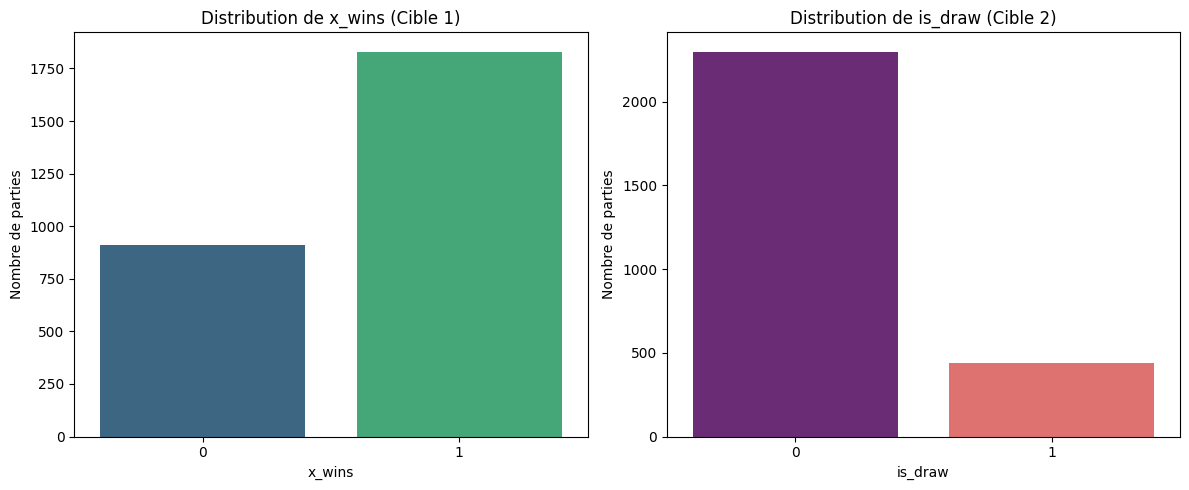

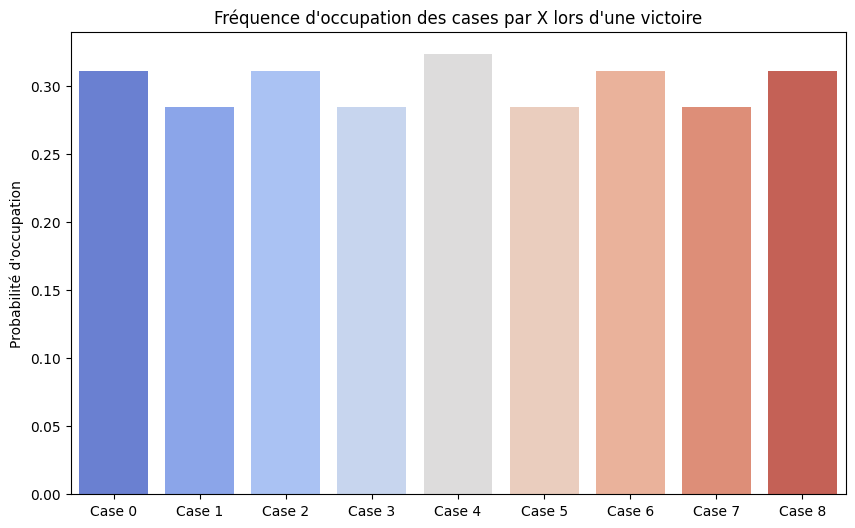

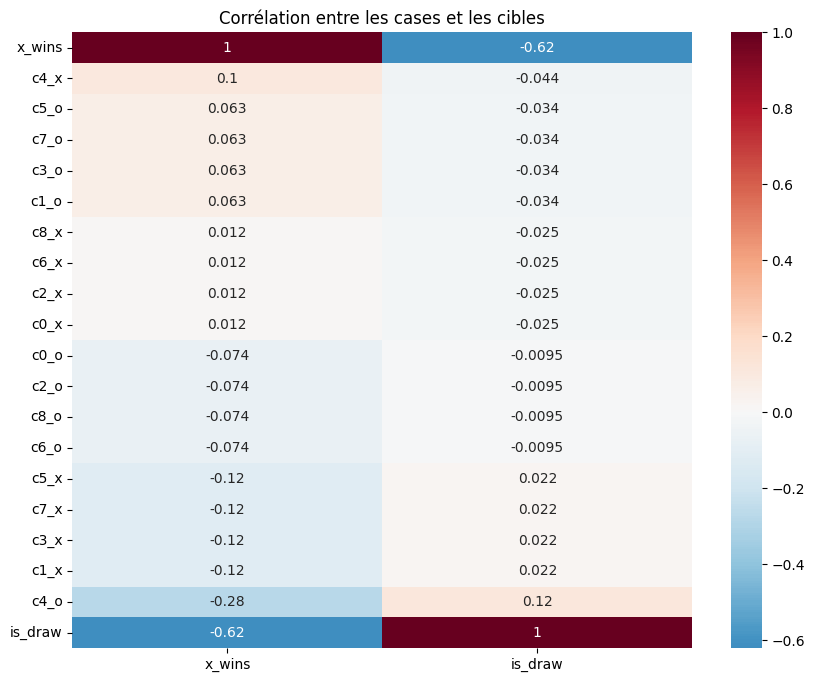

In [14]:


# ---------------------------------------------------------
# ÉTAPE 1 — EDA (Exploratory Data Analysis)
# ---------------------------------------------------------

# 1. Chargement du dataset
df = pd.read_csv('ressources/dataset.csv')

# --- ANALYSE 1 : Distribution des cibles ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Correction : on assigne x à hue et on désactive la légende
sns.countplot(x='x_wins', data=df, hue='x_wins', palette='viridis', legend=False)
plt.title('Distribution de x_wins (Cible 1)')
plt.ylabel('Nombre de parties')

plt.subplot(1, 2, 2)
# Correction identique
sns.countplot(x='is_draw', data=df, hue='is_draw', palette='magma', legend=False)
plt.title('Distribution de is_draw (Cible 2)')
plt.ylabel('Nombre de parties')

plt.tight_layout()
plt.show()

# --- ANALYSE 2 : Occupation des cases par X quand il gagne ---
df_wins = df[df['x_wins'] == 1]
x_occupancy = [df_wins[f'c{i}_x'].mean() for i in range(9)]
case_names = [f"Case {i}" for i in range(9)]

plt.figure(figsize=(10, 6))
# Correction : x est assigné à hue pour éviter le warning
sns.barplot(x=case_names, y=x_occupancy, hue=case_names, palette='coolwarm', legend=False)
plt.title('Fréquence d\'occupation des cases par X lors d\'une victoire')
plt.ylabel('Probabilité d\'occupation')
plt.show()

# --- ANALYSE 3 : Heatmap de corrélation ---
plt.figure(figsize=(10, 8))
# On se concentre sur la corrélation avec les cibles
target_corr = df.corr()[['x_wins', 'is_draw']].sort_values(by='x_wins', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Corrélation entre les cases et les cibles')
plt.show()




--- Modèle A : x_wins ---
Accuracy: 0.6861
F1-Score: 0.7850
              precision    recall  f1-score   support

           0       0.52      0.35      0.42       177
           1       0.73      0.85      0.79       371

    accuracy                           0.69       548
   macro avg       0.63      0.60      0.60       548
weighted avg       0.66      0.69      0.67       548



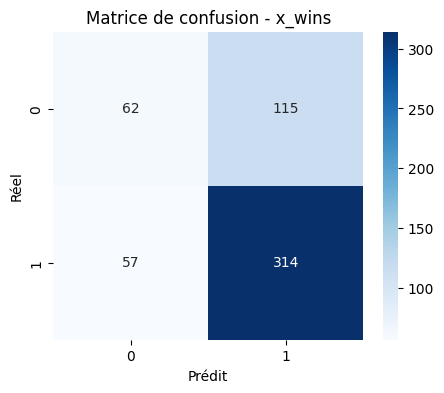


--- Modèle B : is_draw ---
Accuracy: 0.8376
F1-Score: 0.0000
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       459
           1       0.00      0.00      0.00        89

    accuracy                           0.84       548
   macro avg       0.42      0.50      0.46       548
weighted avg       0.70      0.84      0.76       548



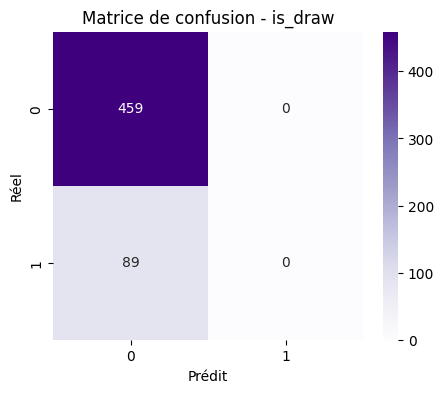


--- Comparaison des modèles ---
x_wins  -> Accuracy: 0.6861 | F1: 0.7850
is_draw -> Accuracy: 0.8376 | F1: 0.0000

👉 Le modèle x_wins est plus facile à apprendre.
Raison : Gagner dépend de patterns simples (alignements).
Le nul est plus complexe car il dépend de toute la stratégie.


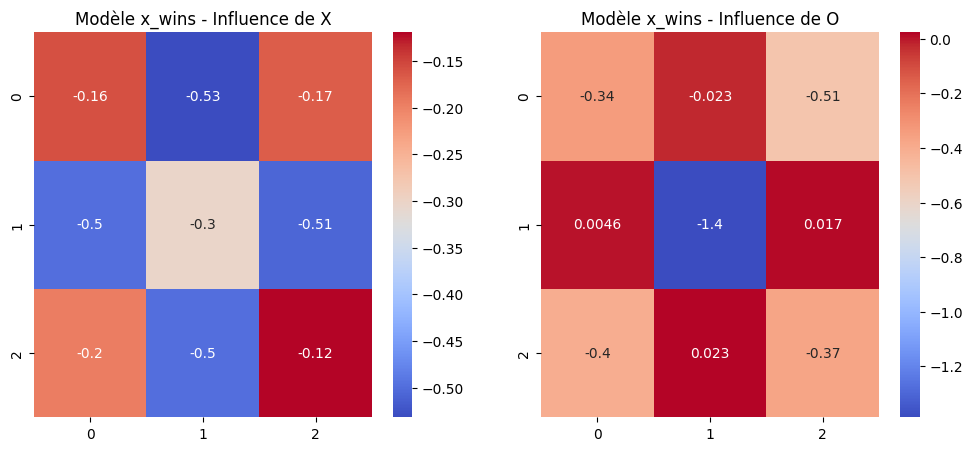


--- Analyse Modèle x_wins ---
Valeurs positives → favorisent la prédiction
Valeurs négatives → défavorisent la prédiction
Influence centre (X): -0.3032
Influence centre (O): -1.3863
👉 Le centre n'est pas dominant pour X


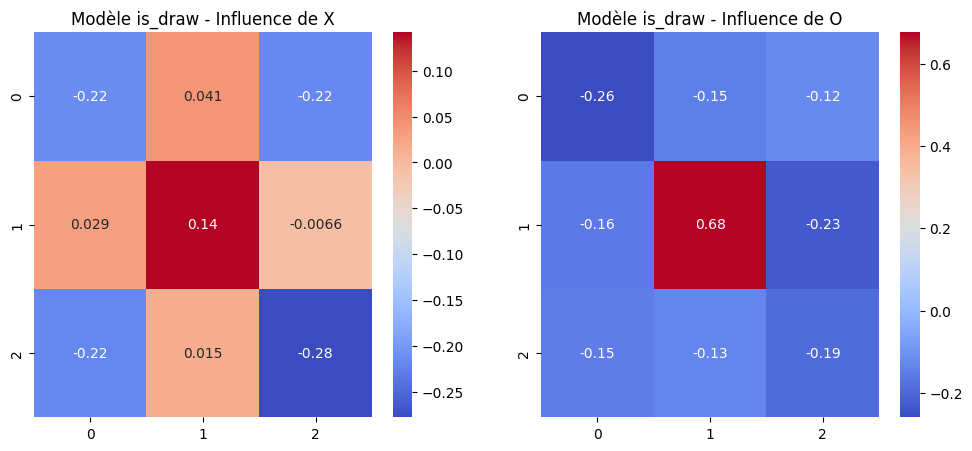


--- Analyse Modèle is_draw ---
Valeurs positives → favorisent la prédiction
Valeurs négatives → défavorisent la prédiction
Influence centre (X): 0.1419
Influence centre (O): 0.6767
👉 Le centre n'est pas dominant pour X


In [13]:
# ---------------------------------------------------------
# ÉTAPE 2 — BASELINE (Régression Logistique)
# ---------------------------------------------------------


# ---------------------------
# 1. Chargement des données
# ---------------------------
df = pd.read_csv('ressources/dataset.csv')

X = df.drop(columns=['x_wins', 'is_draw'])
y_x_wins = df['x_wins']
y_is_draw = df['is_draw']

# Split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y_x_wins, y_is_draw, test_size=0.2, random_state=42
)

# ---------------------------
# 2. Modèle A : x_wins
# ---------------------------
print("\n--- Modèle A : x_wins ---")

model_x = LogisticRegression(max_iter=1000)
model_x.fit(X_train, y1_train)

y1_pred = model_x.predict(X_test)

acc1 = accuracy_score(y1_test, y1_pred)
f1_1 = f1_score(y1_test, y1_pred)

print(f"Accuracy: {acc1:.4f}")
print(f"F1-Score: {f1_1:.4f}")
print(classification_report(y1_test, y1_pred, zero_division=0))

# 🔥 Matrice de confusion
cm1 = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - x_wins")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


# ---------------------------
# 3. Modèle B : is_draw
# ---------------------------
print("\n--- Modèle B : is_draw ---")

model_draw = LogisticRegression(max_iter=1000)
model_draw.fit(X_train, y2_train)

y2_pred = model_draw.predict(X_test)

acc2 = accuracy_score(y2_test, y2_pred)
f1_2 = f1_score(y2_test, y2_pred)

print(f"Accuracy: {acc2:.4f}")
print(f"F1-Score: {f1_2:.4f}")
print(classification_report(y2_test, y2_pred, zero_division=0))

# 🔥 Matrice de confusion
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples')
plt.title("Matrice de confusion - is_draw")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


# ---------------------------
# 4. Comparaison des modèles
# ---------------------------
print("\n--- Comparaison des modèles ---")
print(f"x_wins  -> Accuracy: {acc1:.4f} | F1: {f1_1:.4f}")
print(f"is_draw -> Accuracy: {acc2:.4f} | F1: {f1_2:.4f}")

if f1_1 > f1_2:
    print("\n👉 Le modèle x_wins est plus facile à apprendre.")
    print("Raison : Gagner dépend de patterns simples (alignements).")
    print("Le nul est plus complexe car il dépend de toute la stratégie.")
else:
    print("\n👉 Le modèle is_draw est plus facile (cas rare).")


# ---------------------------
# 5. Analyse des coefficients
# ---------------------------
def plot_coefficients(model, title):
    coefs = model.coef_[0]

    coefs_x = coefs[0::2].reshape(3, 3)
    coefs_o = coefs[1::2].reshape(3, 3)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(coefs_x, annot=True, cmap='coolwarm', ax=ax[0])
    ax[0].set_title(f'{title} - Influence de X')

    sns.heatmap(coefs_o, annot=True, cmap='coolwarm', ax=ax[1])
    ax[1].set_title(f'{title} - Influence de O')

    plt.show()

    # 🔥 Interprétation rapide
    print(f"\n--- Analyse {title} ---")
    print("Valeurs positives → favorisent la prédiction")
    print("Valeurs négatives → défavorisent la prédiction")

    center_x = coefs[8]   # c4_x (centre)
    center_o = coefs[9]   # c4_o (centre)

    print(f"Influence centre (X): {center_x:.4f}")
    print(f"Influence centre (O): {center_o:.4f}")

    if abs(center_x) > np.mean(np.abs(coefs)):
        print("👉 Le centre est une case STRATÉGIQUE importante pour X")
    else:
        print("👉 Le centre n'est pas dominant pour X")


# Visualisation
plot_coefficients(model_x, "Modèle x_wins")
plot_coefficients(model_draw, "Modèle is_draw")

--- Entraînement Random Forest ---

Résultats pour x_wins
Accuracy: 0.8631
F1-score: 0.9032
              precision    recall  f1-score   support

           0       0.85      0.69      0.77       177
           1       0.87      0.94      0.90       371

    accuracy                           0.86       548
   macro avg       0.86      0.82      0.83       548
weighted avg       0.86      0.86      0.86       548



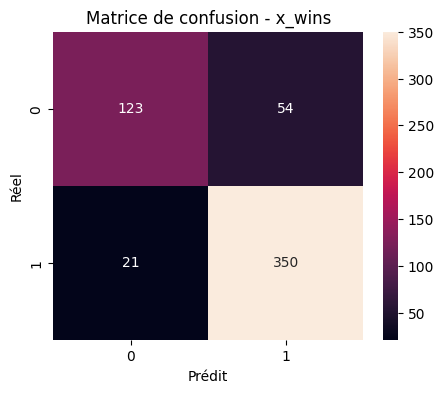


Résultats pour is_draw
Accuracy: 0.9015
F1-score: 0.5714
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       459
           1       0.97      0.40      0.57        89

    accuracy                           0.90       548
   macro avg       0.93      0.70      0.76       548
weighted avg       0.91      0.90      0.88       548



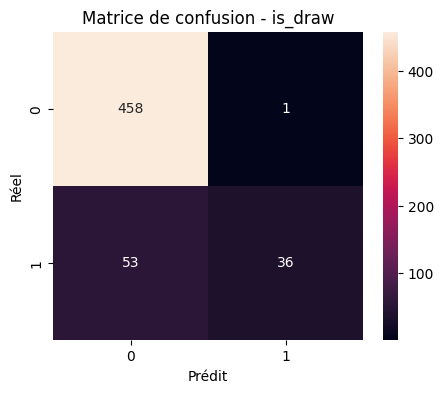


--- Comparaison ---
x_wins  -> Accuracy: 0.8631, F1: 0.9032
is_draw -> Accuracy: 0.9015, F1: 0.5714
Le modèle x_wins est plus facile à apprendre.
Les motifs de victoire sont plus simples (alignements).

Comparaison avec la régression logistique :
Random Forest capture des relations non linéaires.
Elle est donc généralement plus performante.


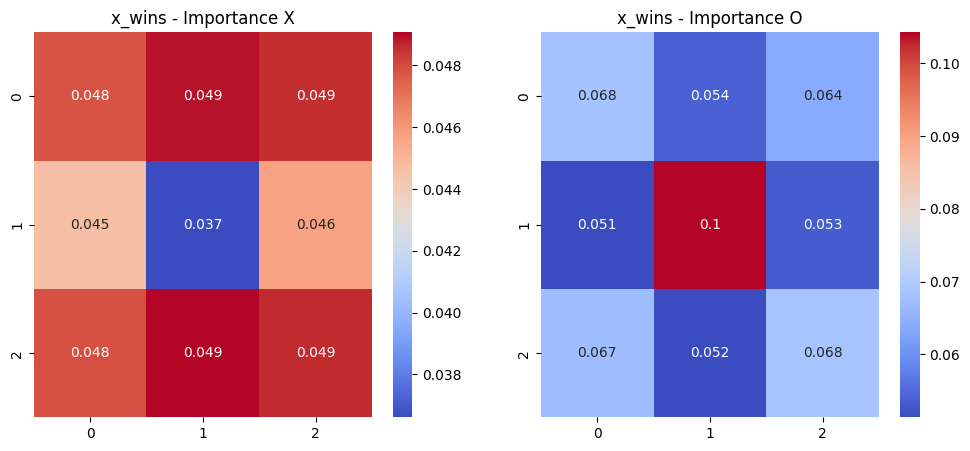


Analyse x_wins
Importance centre (X): 0.0366
Importance centre (O): 0.1043


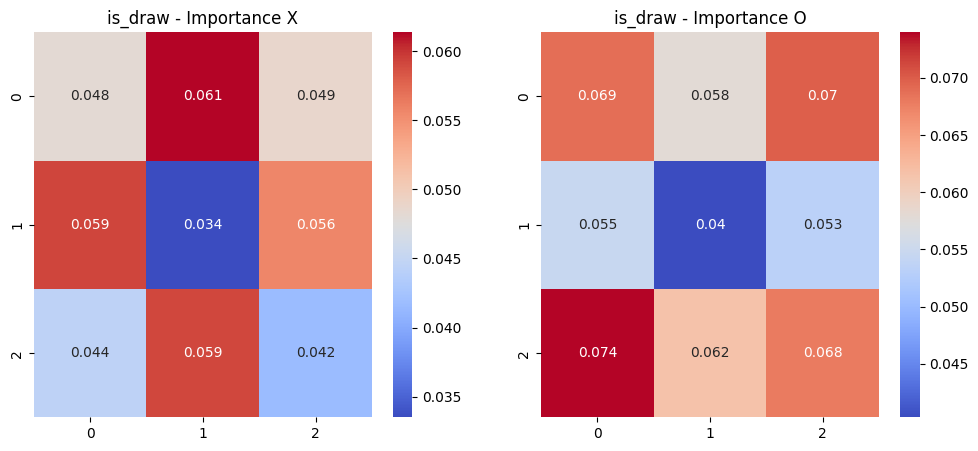


Analyse is_draw
Importance centre (X): 0.0335
Importance centre (O): 0.0403

Modèles sauvegardés dans 'ressources/'


In [11]:
# ---------------------------------------------------------
# ÉTAPE 3 — MODÈLE AVANCÉ (Random Forest)
# ---------------------------------------------------------
# ---------------------------------------------------------
# 1. Chargement et préparation des données
# ---------------------------------------------------------
df = pd.read_csv('ressources/dataset.csv')

X = df.drop(columns=['x_wins', 'is_draw'])
y_x = df['x_wins']
y_draw = df['is_draw']

# Split 80/20
X_train, X_test, yx_train, yx_test, yd_train, yd_test = train_test_split(
    X, y_x, y_draw, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 2. Entraînement des modèles Random Forest
# ---------------------------------------------------------
print("--- Entraînement Random Forest ---")

rf_x = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
rf_draw = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)

rf_x.fit(X_train, yx_train)
rf_draw.fit(X_train, yd_train)

# ---------------------------------------------------------
# 3. Évaluation
# ---------------------------------------------------------
def evaluer_modele(model, X_t, y_t, nom):
    preds = model.predict(X_t)

    acc = accuracy_score(y_t, preds)
    f1 = f1_score(y_t, preds)

    print(f"\nRésultats pour {nom}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(classification_report(y_t, preds, zero_division=0))

    # Matrice de confusion
    cm = confusion_matrix(y_t, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Matrice de confusion - {nom}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    return acc, f1


acc_x, f1_x = evaluer_modele(rf_x, X_test, yx_test, "x_wins")
acc_d, f1_d = evaluer_modele(rf_draw, X_test, yd_test, "is_draw")

# ---------------------------------------------------------
# 4. Comparaison des modèles
# ---------------------------------------------------------
print("\n--- Comparaison ---")
print(f"x_wins  -> Accuracy: {acc_x:.4f}, F1: {f1_x:.4f}")
print(f"is_draw -> Accuracy: {acc_d:.4f}, F1: {f1_d:.4f}")

if f1_x > f1_d:
    print("Le modèle x_wins est plus facile à apprendre.")
    print("Les motifs de victoire sont plus simples (alignements).")
else:
    print("Le modèle is_draw est plus facile (cas rare).")

print("\nComparaison avec la régression logistique :")
print("Random Forest capture des relations non linéaires.")
print("Elle est donc généralement plus performante.")

# ---------------------------------------------------------
# 5. Feature Importance (IMPORTANT)
# ---------------------------------------------------------
def plot_importance(model, titre):
    importances = model.feature_importances_

    # Séparation X et O
    imp_x = importances[0::2].reshape(3, 3)
    imp_o = importances[1::2].reshape(3, 3)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(imp_x, annot=True, cmap='coolwarm', ax=ax[0])
    ax[0].set_title(f"{titre} - Importance X")

    sns.heatmap(imp_o, annot=True, cmap='coolwarm', ax=ax[1])
    ax[1].set_title(f"{titre} - Importance O")

    plt.show()

    # Analyse simple du centre
    center_x = importances[8]
    center_o = importances[9]

    print(f"\nAnalyse {titre}")
    print(f"Importance centre (X): {center_x:.4f}")
    print(f"Importance centre (O): {center_o:.4f}")


plot_importance(rf_x, "x_wins")
plot_importance(rf_draw, "is_draw")

# ---------------------------------------------------------
# 6. Sauvegarde des modèles
# ---------------------------------------------------------
joblib.dump(rf_x, 'ressources/model_x_wins_final.pkl')
joblib.dump(rf_draw, 'ressources/model_is_draw_final.pkl')

print("\nModèles sauvegardés dans 'ressources/'")